# Отчет к Лабораторной работе №2 "Интерполяция"

Шуман Владислав Олегович

3 курс, 4 группа

Вариант 2A

[Github](https://github.com/UladzislauShuman/university_homework/tree/numerical_methods-lab3/famcs_homework/numerical_methods/6sem/lab2)

Время последнего изменения: 23.03.2026

Часть из электронных конспектов, которую я использовал: [тут](https://github.com/UladzislauShuman/university_homework/tree/numerical_methods-lab3/famcs_homework/numerical_methods/6sem/%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F/%D0%BB%D0%B0%D0%B12)


# Условие

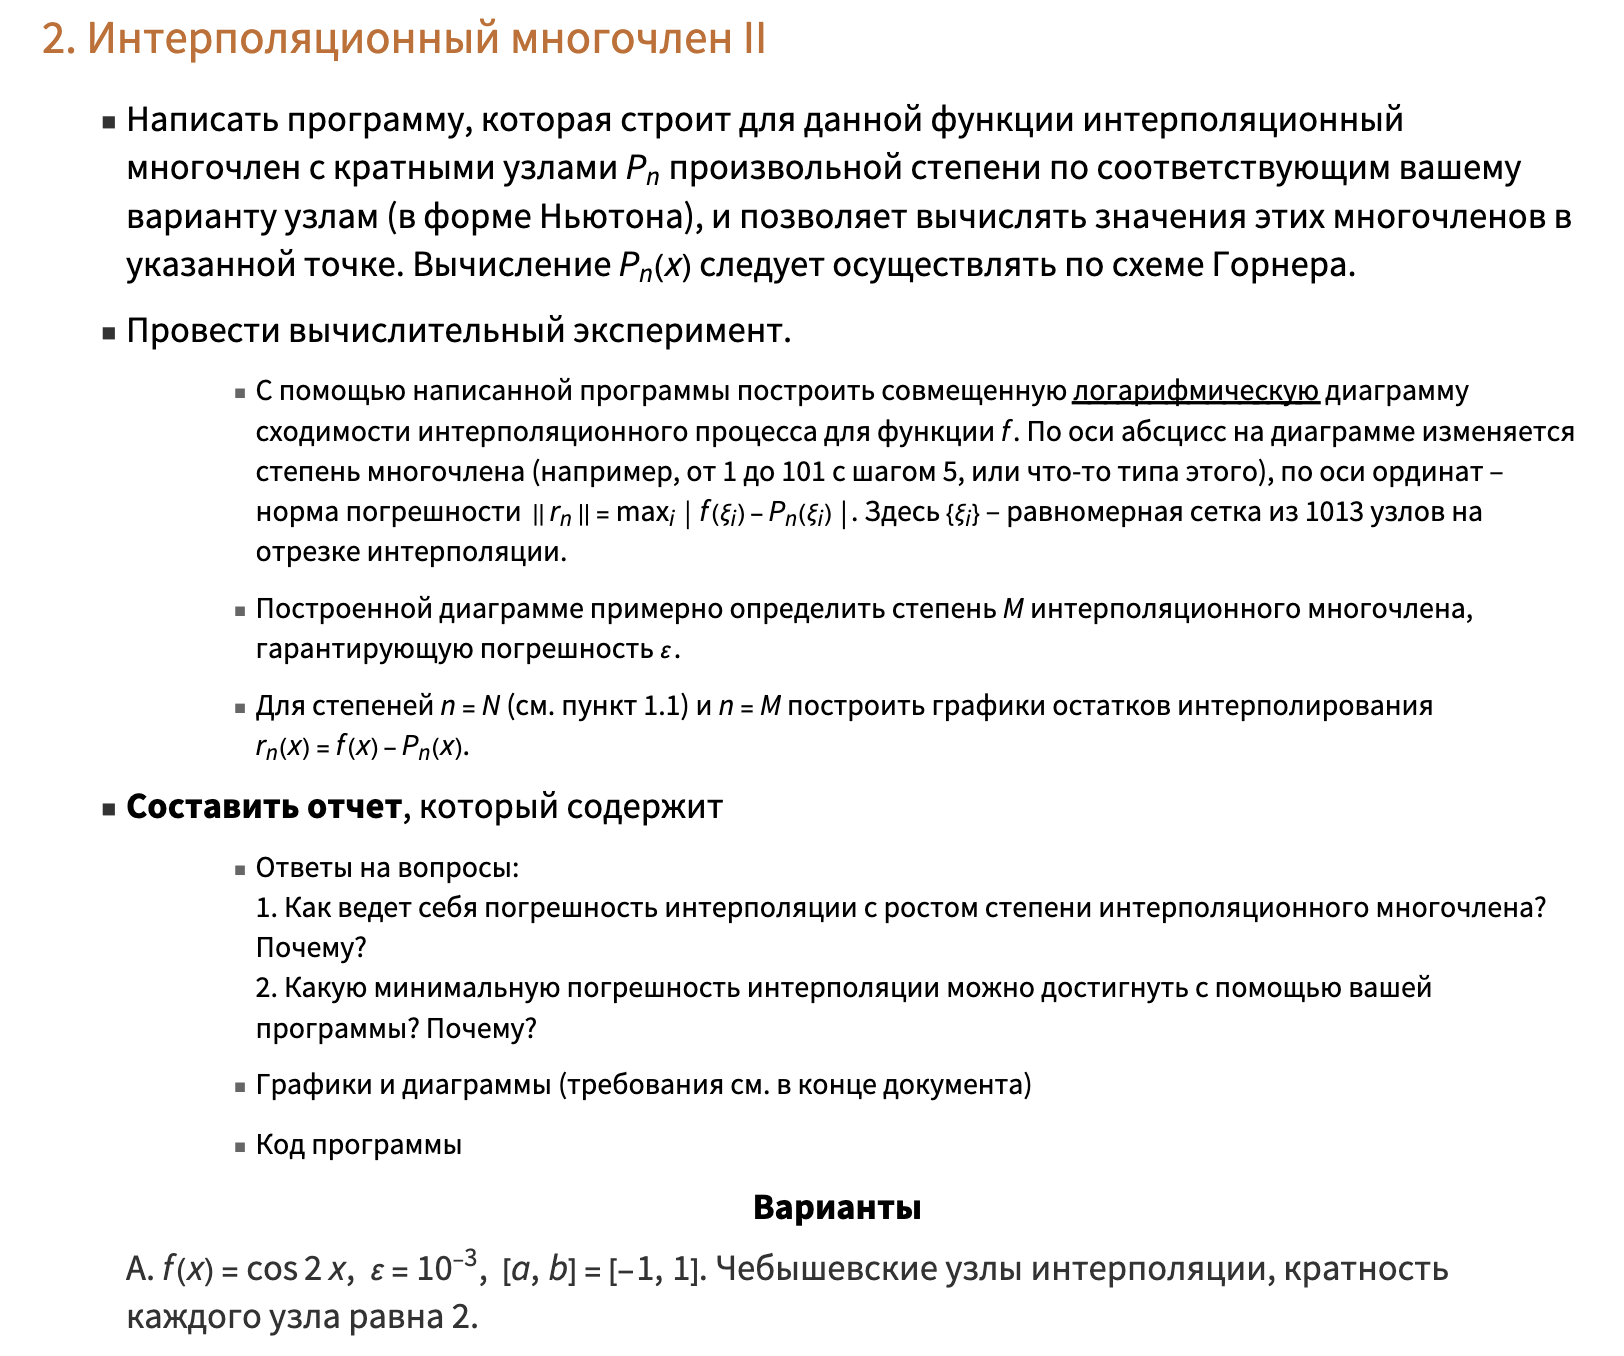

пункт 1.1

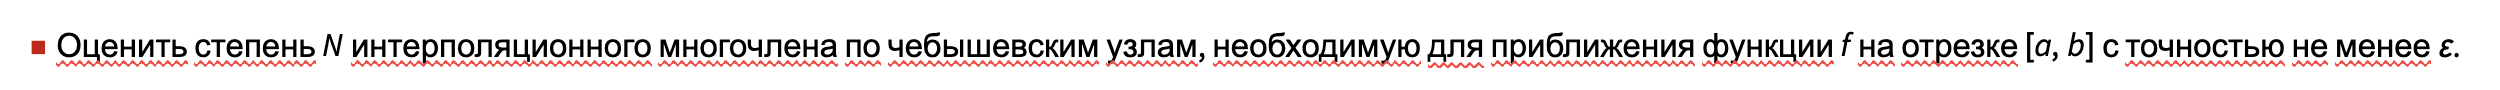

# Решение

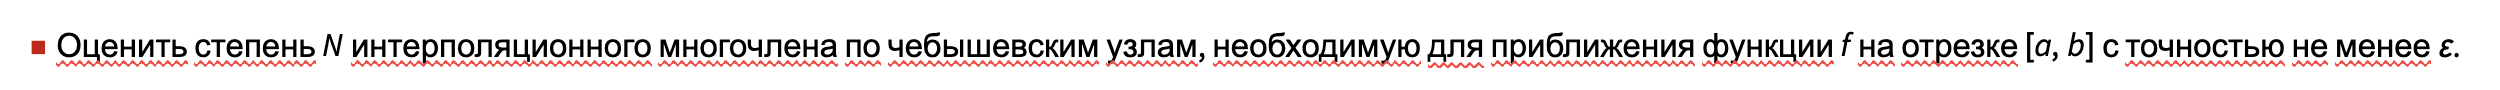

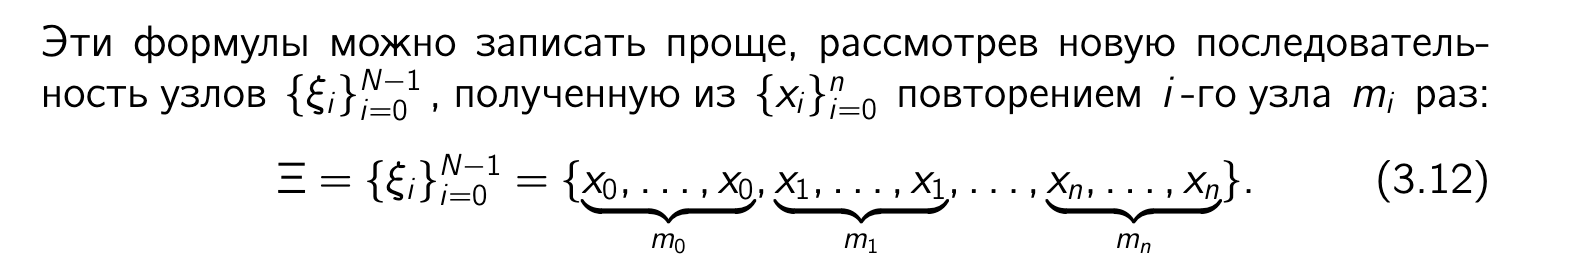

3.13

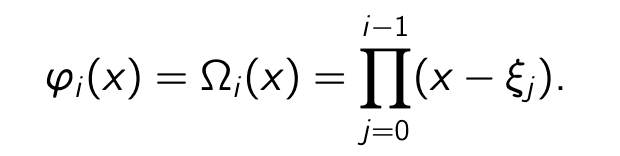

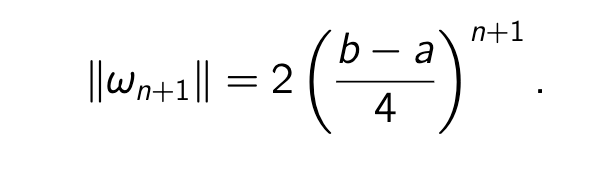

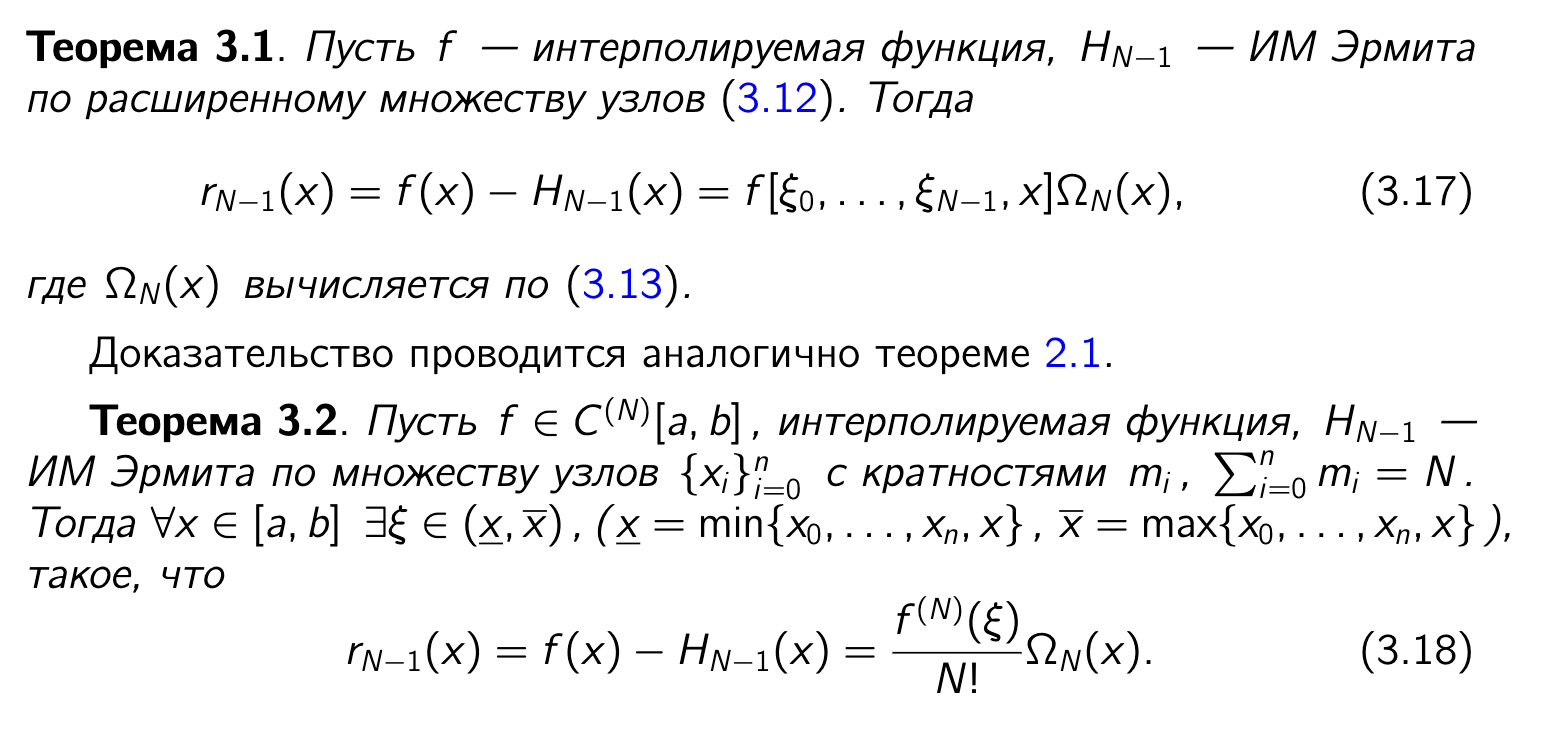

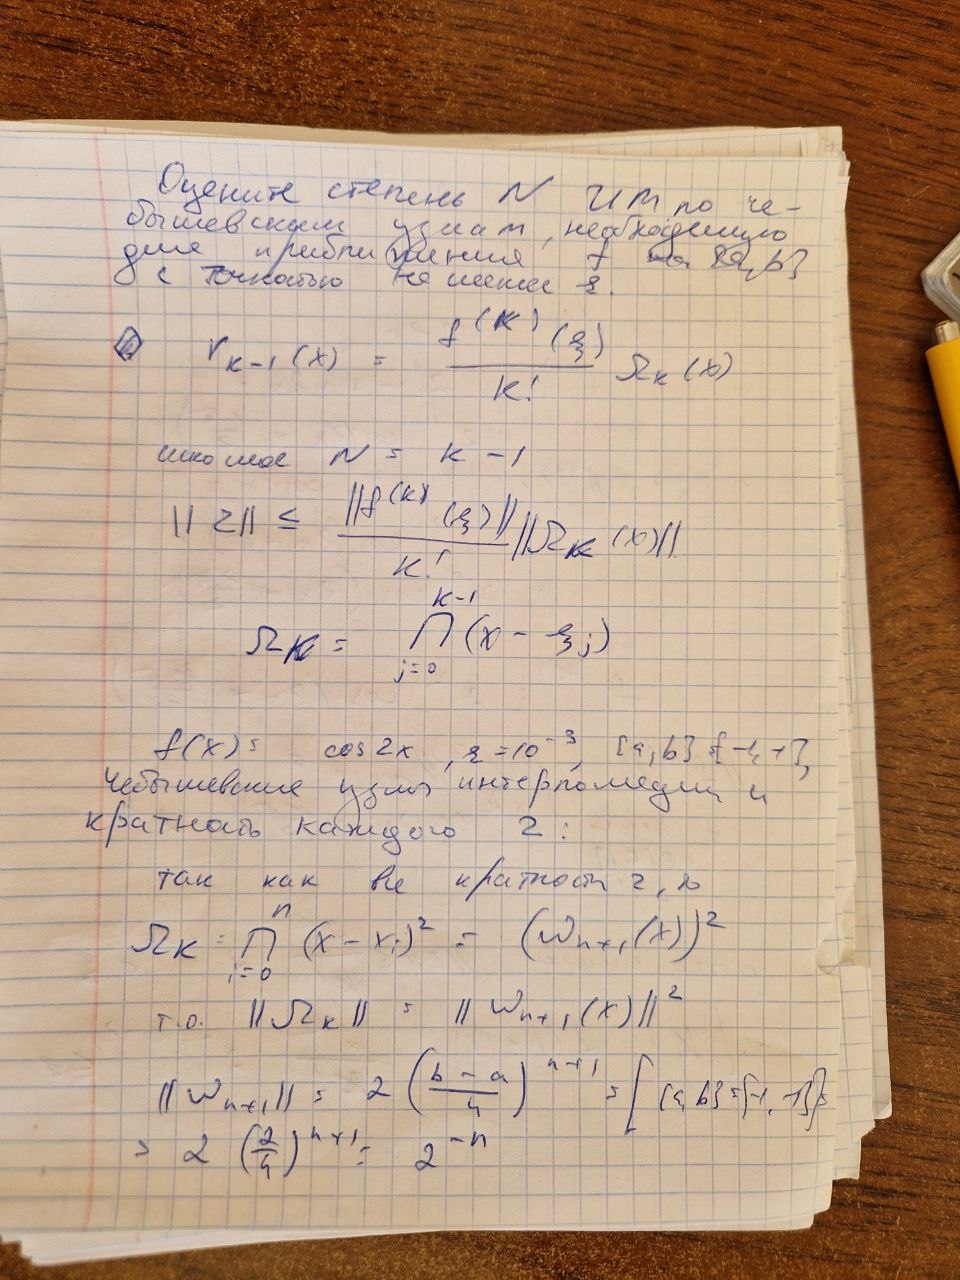

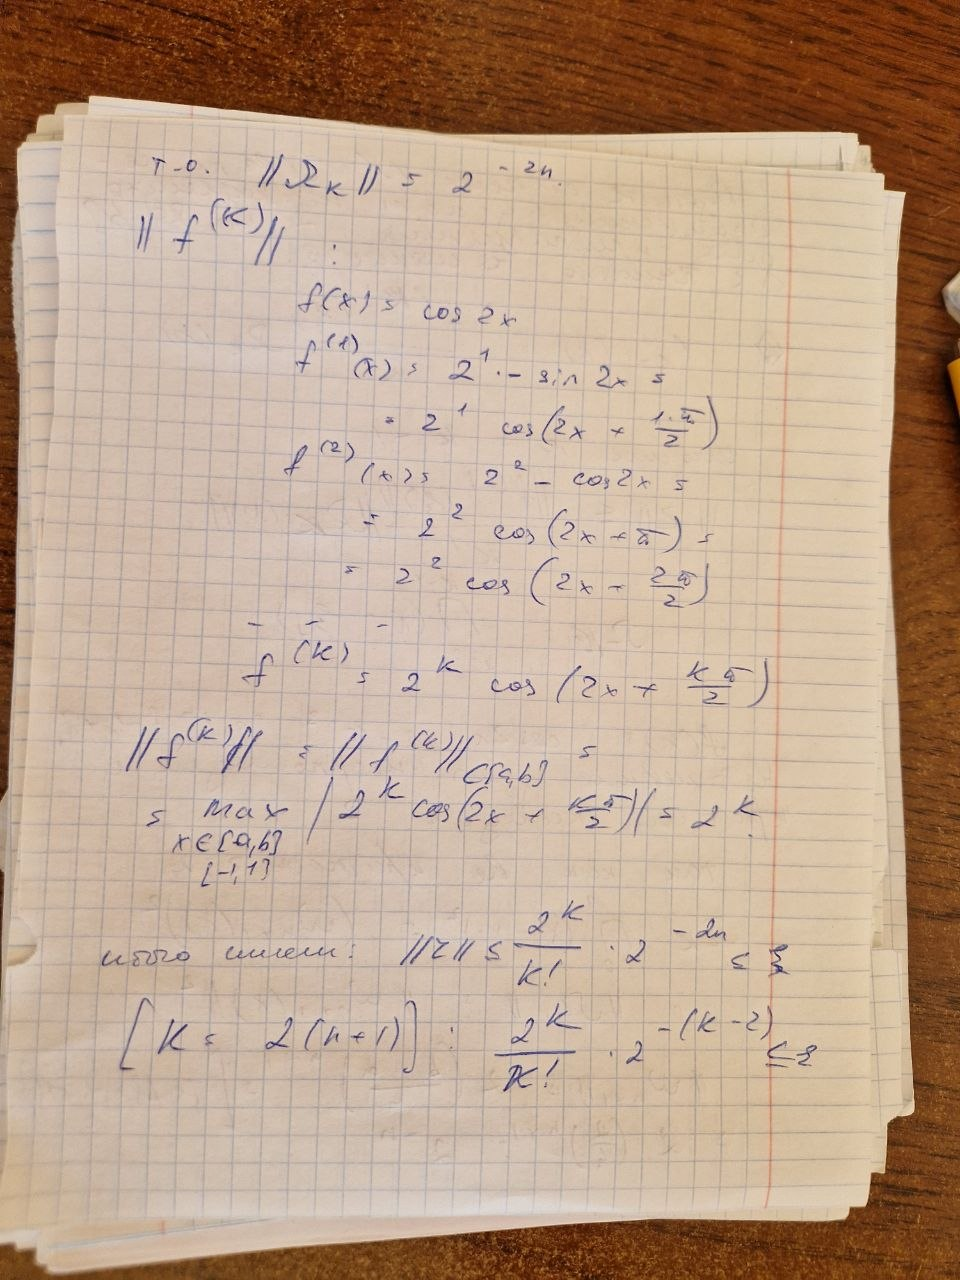

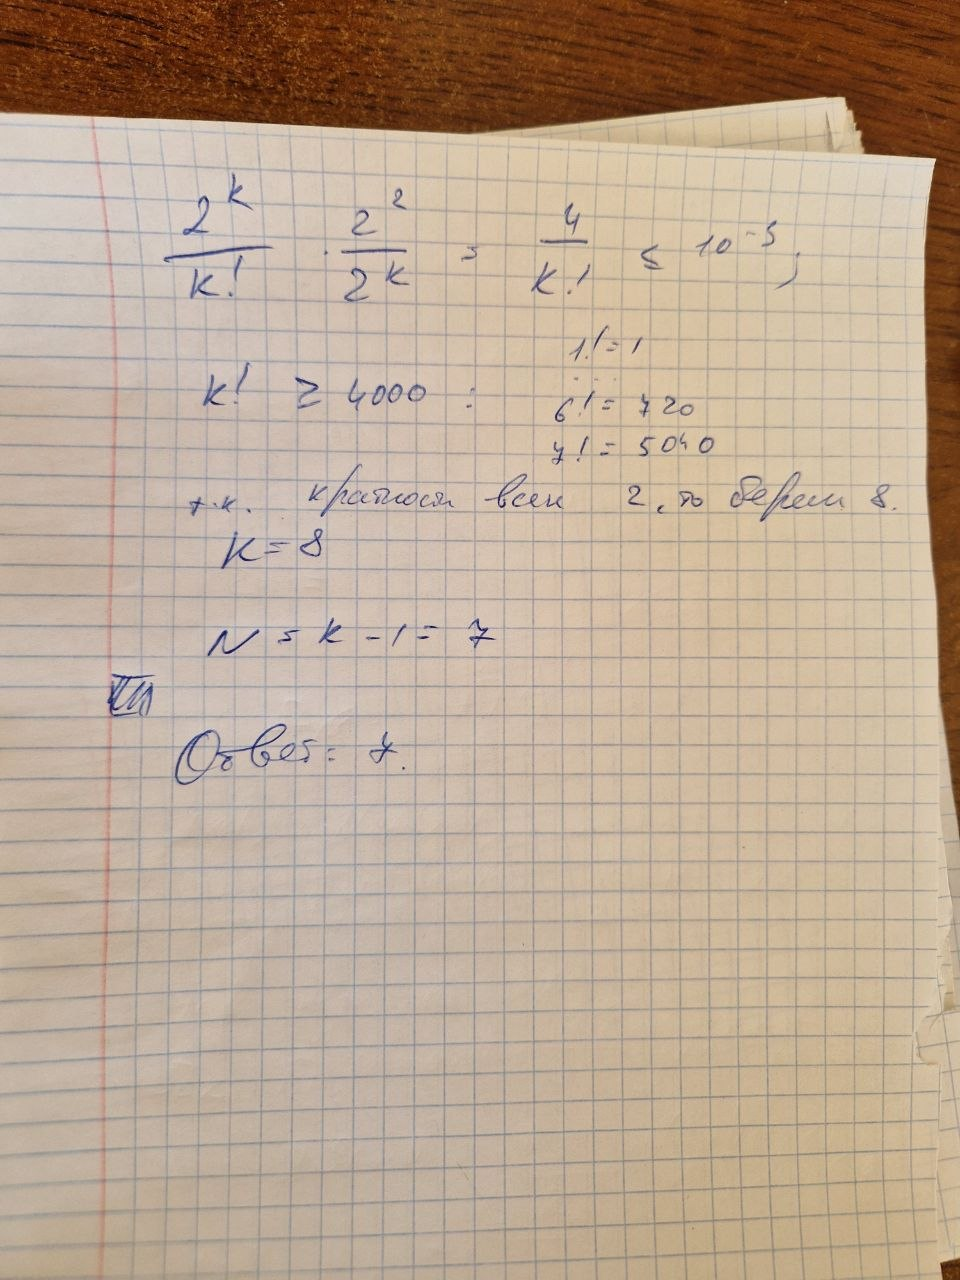

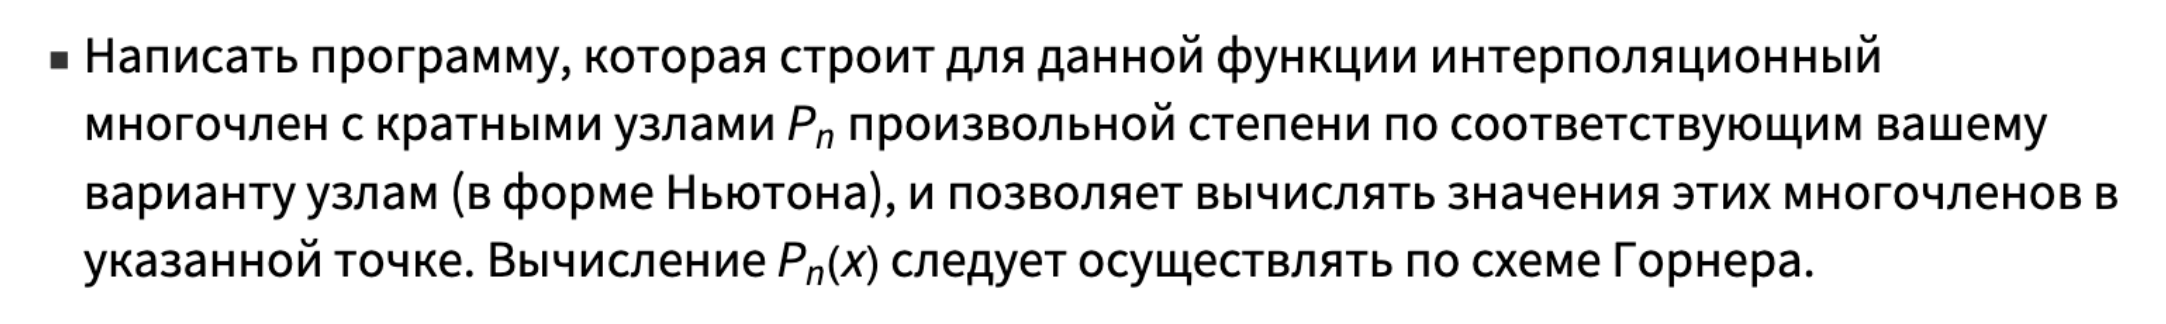

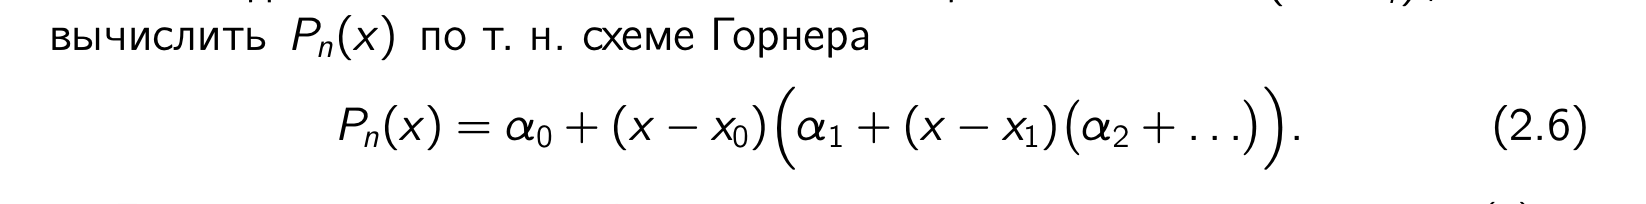

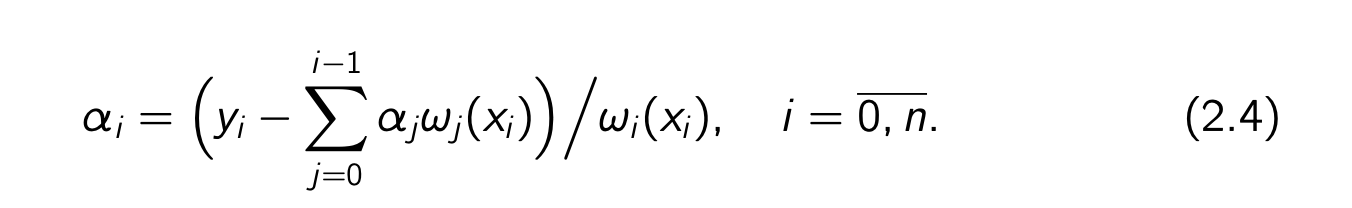

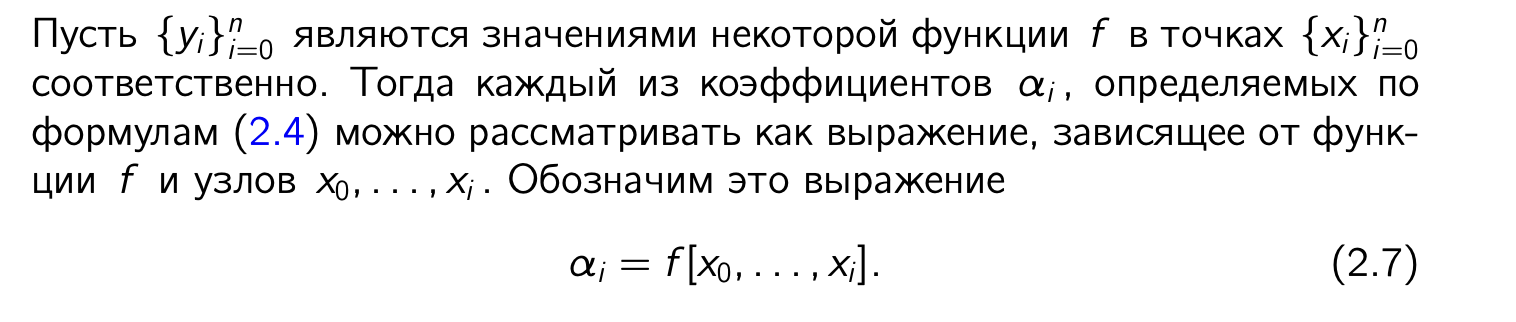

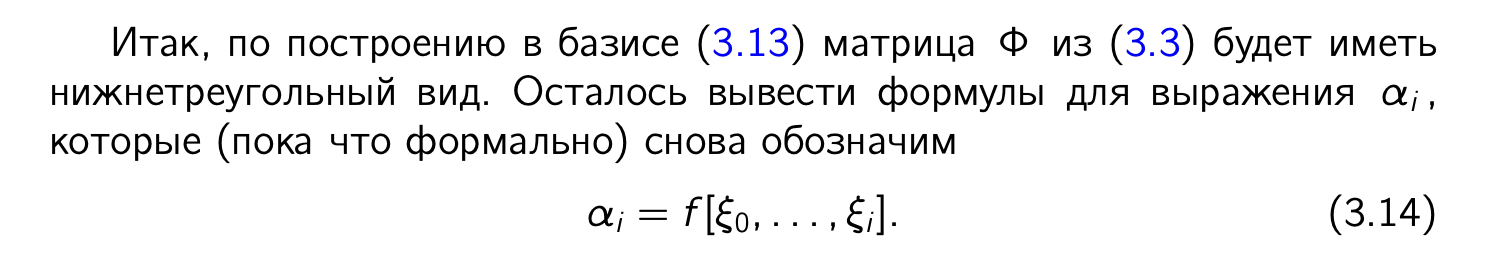

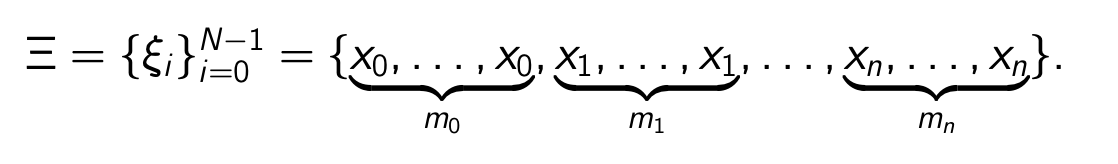

$\Xi = \{x_0, x_0, x_1, x_1, \dots, x_n, x_n\}$.

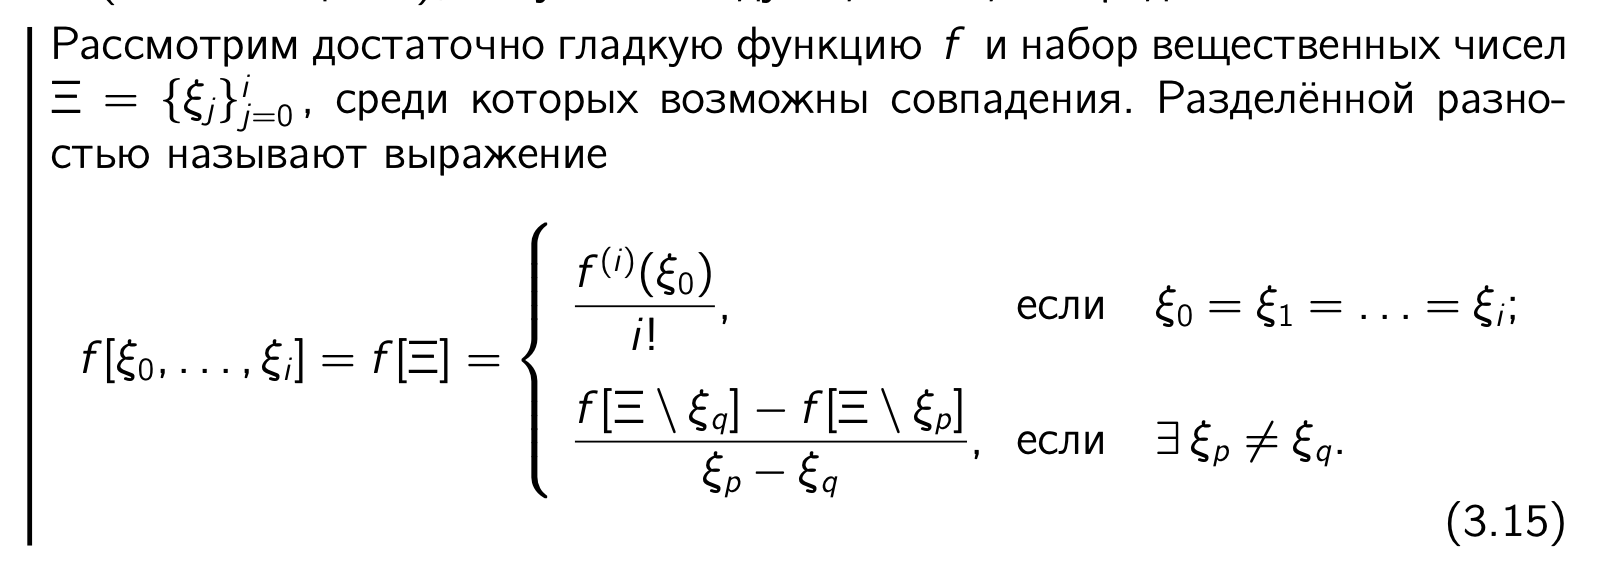

*   Если $x_i \ne x_j$: $\frac{f(x_i) - f(x_j)}{x_i - x_j}$.
*   Если кратны И при условии, что у нас кратность 2: $\frac{f'(x_i)}{1!}$.

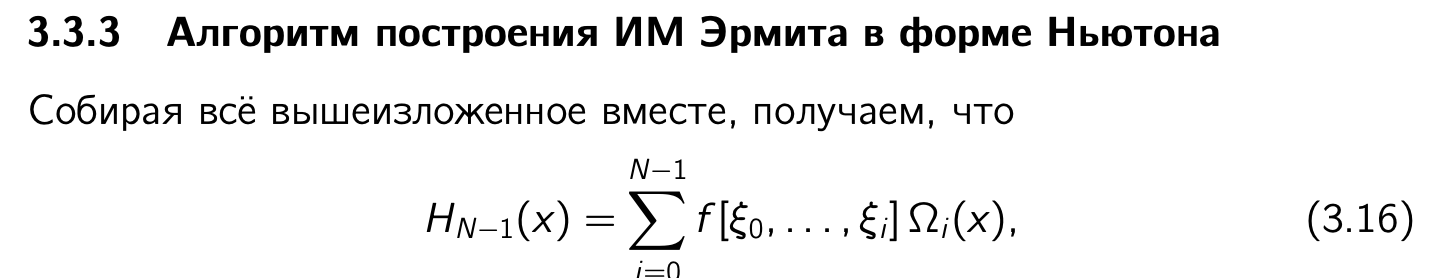

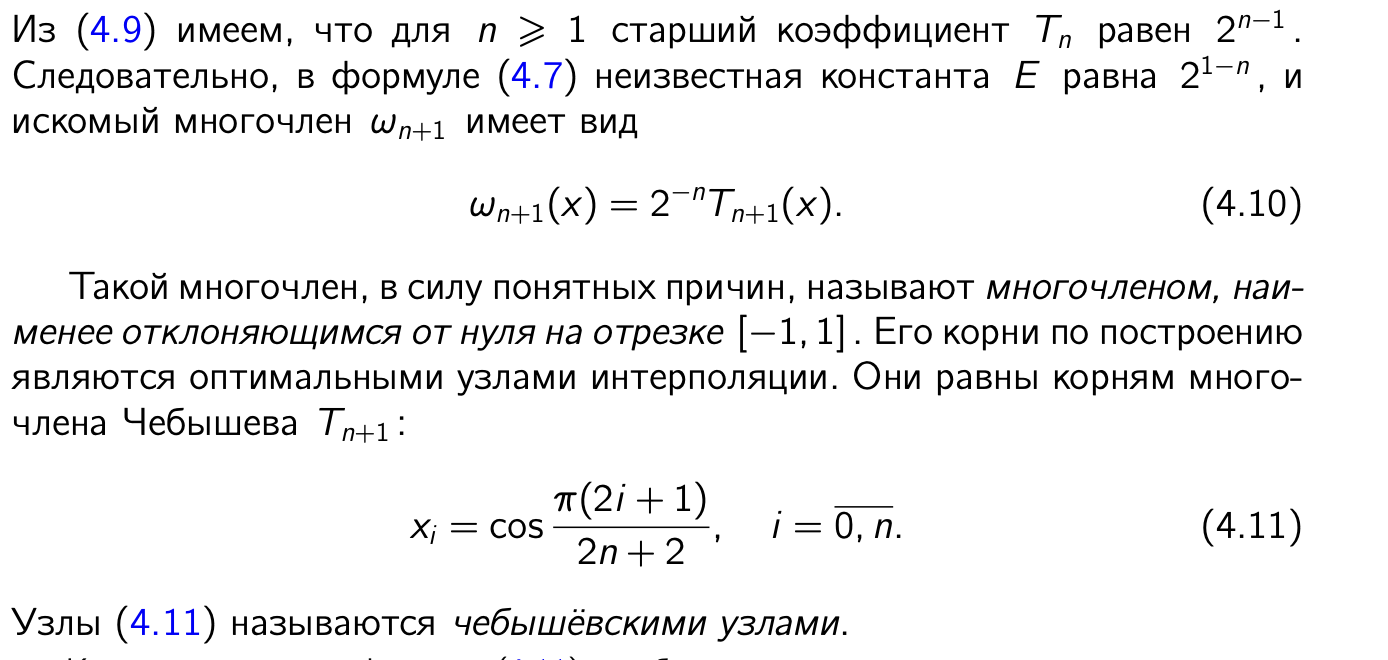

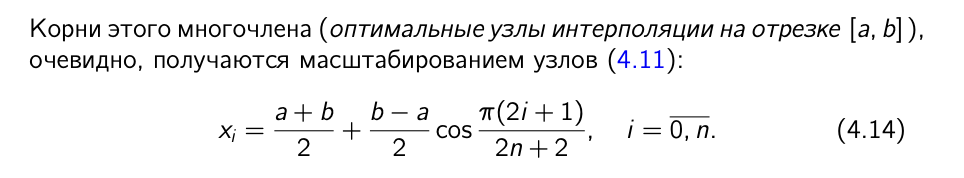

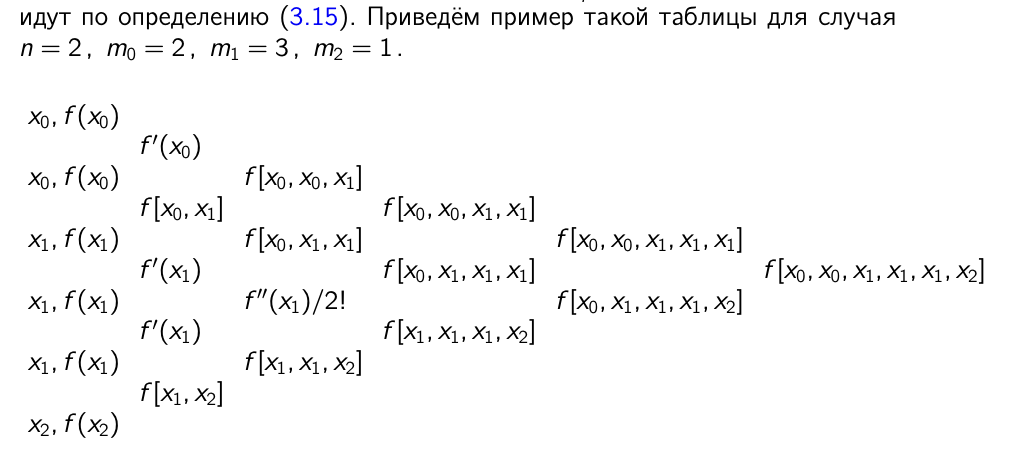

найдем $n$:
$$ K = 2(n + 1) $$
$$ 8 = 2(n + 1) $$
$$ 4 = n + 1 $$
$$ n = 3$$

In [ ]:
import numpy as np

# исходная фунция
def f(x): 
    return np.cos(2 * x)

# ее производная
def df(x):
    return -2 * np.sin(2 * x)

# получить узлы Чебышева
def get_chebyshev_nodes(
    n, # n+1 -- количество различных узлов
    a, b): # [a,b]
    indices = np.arange(n + 1) # массив от 0 до n
    nodes = np.cos((np.pi * (2 * indices + 1)) / (2 * n + 2)) # узлы чебышева
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes # масштабирование

# построение таблицы разделенных разностей для кратных узлов
def build_hermite_table(
    nodes, # уникальные узлы
    multiplicity=2): # кратность каждого узла. по условию 2

    # Xi
    xi = np.repeat(nodes, multiplicity)
    n_total = len(xi)
    
    # таблица разностей: n_total строк на n_total столбцов
    table = np.zeros((n_total, n_total))
    
    # первый столбец: значения функции в узлах
    table[:, 0] = f(xi)
    
    # заполняем остальное
    for j in range(1, n_total):
        for i in range(n_total - j):
            # совпадают ли узлы
            if abs(xi[i+j] - xi[i]) < 1e-12:
                table[i, j] = df(xi[i])
            else:
                table[i, j] = (table[i+1, j-1] - table[i, j-1]) / (xi[i+j] - xi[i])
                
    return xi, table[0, :]

# схема Горнера
def hornering(x, xi, alphas):
    n = len(alphas)
    res = alphas[-1]
    for i in range(n - 2, -1, -1):
        res = res * (x - xi[i]) + alphas[i]
    return res

a, b = -1, 1
n = 3 

# узлы
unique_nodes = get_chebyshev_nodes(n, a, b)

# таблица и альфы
xi_expanded, alphas = build_hermite_table(unique_nodes)

# пробуем что=то вычеслить
x_test = 0.5
y_poly = hornering(x_test, xi_expanded, alphas)
y_true = f(x_test)

print(f"степень многочлена: {len(alphas)-1}")
print(f"значение в x={x_test}: {y_poly}")
print(f"точное значение: {y_true}")
print(f"ошибка: {abs(y_poly - y_true)}")

степень многочлена: 7
значение в x=0.5: 0.5402798767315129
точное значение: 0.5403023058681398
ошибка: 2.2429136626866963e-05


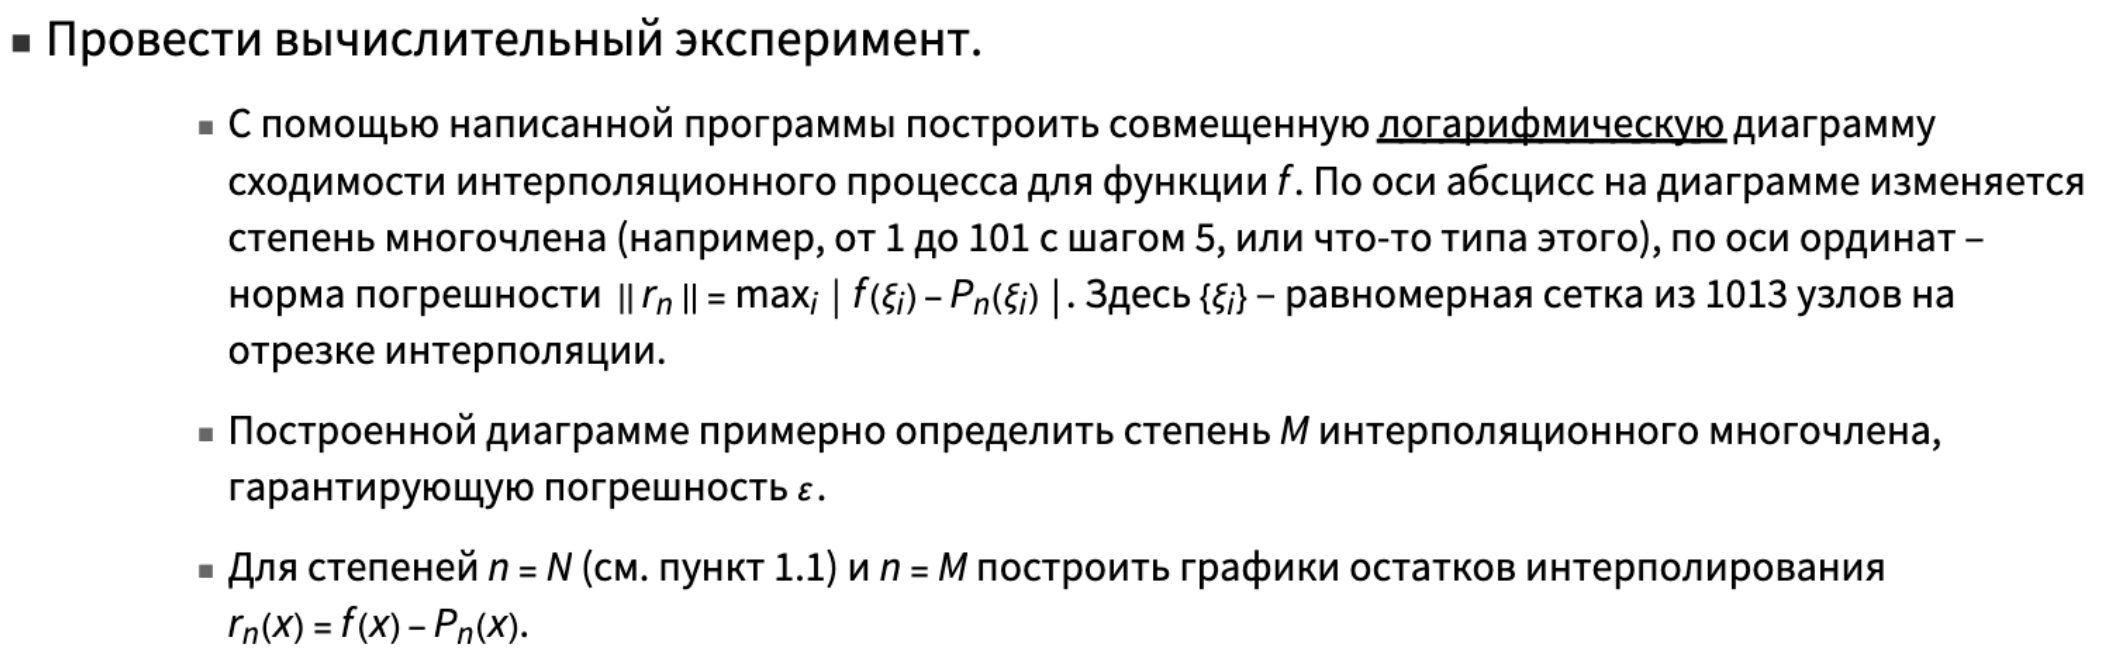

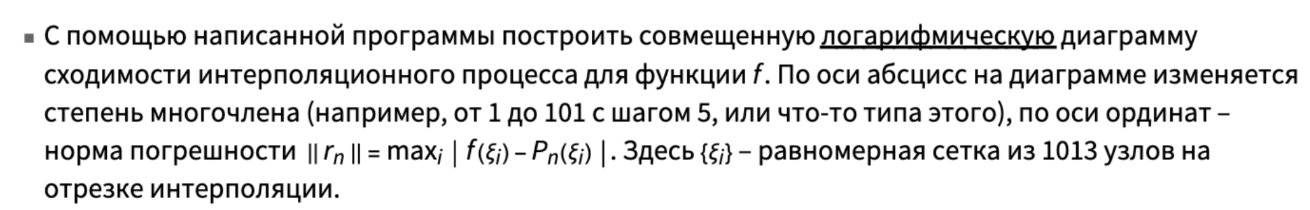

start...
степень:   1 | ошибка: 1.42e+00
степень:   3 | ошибка: 1.46e-01
степень:   5 | ошибка: 4.90e-03
степень:   7 | ошибка: 9.07e-05
степень:   9 | ошибка: 1.02e-06
степень:  11 | ошибка: 7.82e-09
степень:  13 | ошибка: 4.32e-11
степень:  15 | ошибка: 1.81e-13
степень:  17 | ошибка: 1.78e-15
степень:  19 | ошибка: 1.83e-15
степень:  21 | ошибка: 1.61e-15
степень:  23 | ошибка: 1.33e-15
степень:  25 | ошибка: 1.21e-15
степень:  27 | ошибка: 1.28e-15
степень:  29 | ошибка: 1.61e-15
степень:  31 | ошибка: 2.22e-15
степень:  33 | ошибка: 1.94e-15
степень:  35 | ошибка: 1.75e-15
степень:  37 | ошибка: 1.39e-15
степень:  39 | ошибка: 1.22e-15
степень:  41 | ошибка: 2.39e-15
степень:  43 | ошибка: 2.58e-14
степень:  45 | ошибка: 3.82e-13
степень:  47 | ошибка: 1.63e-12
степень:  49 | ошибка: 2.66e-11
степень:  51 | ошибка: 2.92e-10
степень:  53 | ошибка: 1.39e-09
степень:  55 | ошибка: 6.07e-09
степень:  57 | ошибка: 5.62e-07
степень:  59 | ошибка: 2.31e-06
степень:  61 | ошибка: 2.68e-06

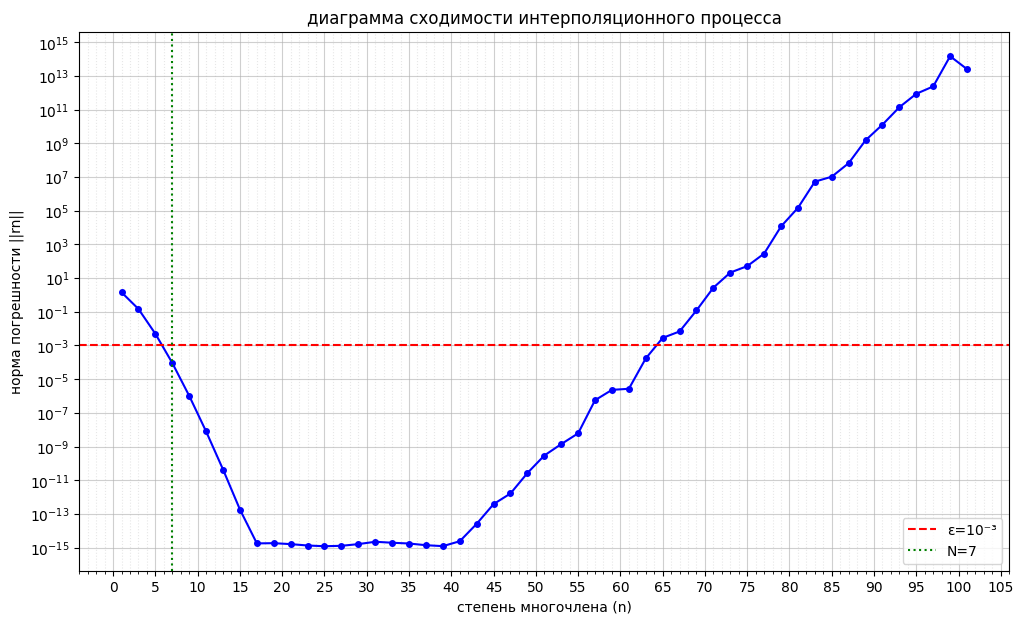

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

xi_control = np.linspace(a, b, 
                         1013) # сетка из 1013 узлов 
y_true_control = f(xi_control)

# результат
degrees = []
errors = []

print("start...")

for target_degree in range(1, 102, 2):
    
    # кол_узлов = (на_степень + 1) / 2
    n_nodes = (target_degree + 1) // 2
    
    # если n_nodes == 0 
    if n_nodes < 1:
        n_nodes = 1
    
    # узлы
    nodes = get_chebyshev_nodes(n_nodes - 1, a, b)
    
    # строим многочлен
    xi_expanded, alphas = build_hermite_table(nodes)
    
    # фактическая степень
    actual_degree = len(alphas) - 1
    
    # ошибка
    y_poly_control = np.array([hornering(x, xi_expanded, alphas) for x in xi_control])
    error_norm = np.max(np.abs(y_true_control - y_poly_control))
    
    # сохраняем
    degrees.append(actual_degree)
    errors.append(error_norm)
    
    print(f"степень: {actual_degree:3} | ошибка: {error_norm:.2e}")



# первая степень, где ошибка < 1e-3
N = next((d for d, e in zip(degrees, errors) if e < 1e-3), None)

# диаграмма
plt.figure(figsize=(12, 7))
plt.plot(degrees, errors, 'bo-', markersize=4)
plt.axhline(y=1e-3, color='r', linestyle='--', label='ε=10⁻³')

if N is not None:
    plt.axvline(x=N, color='g', linestyle=':', label=f'N={N}')

plt.yscale('log')
plt.xlabel('степень многочлена (n)')
plt.ylabel('норма погрешности ||rn||')
plt.title('диаграмма сходимости интерполяционного процесса')

ax = plt.gca()
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=30))
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))

plt.grid(True, which="major", ls="-", alpha=0.6)
plt.grid(True, which="minor", ls=":", alpha=0.3)

plt.legend()
plt.show()

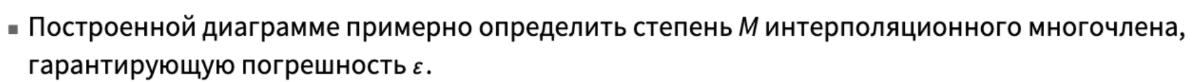

$M = 7 (= N)$ и $M = 65$

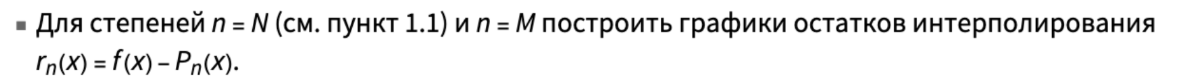

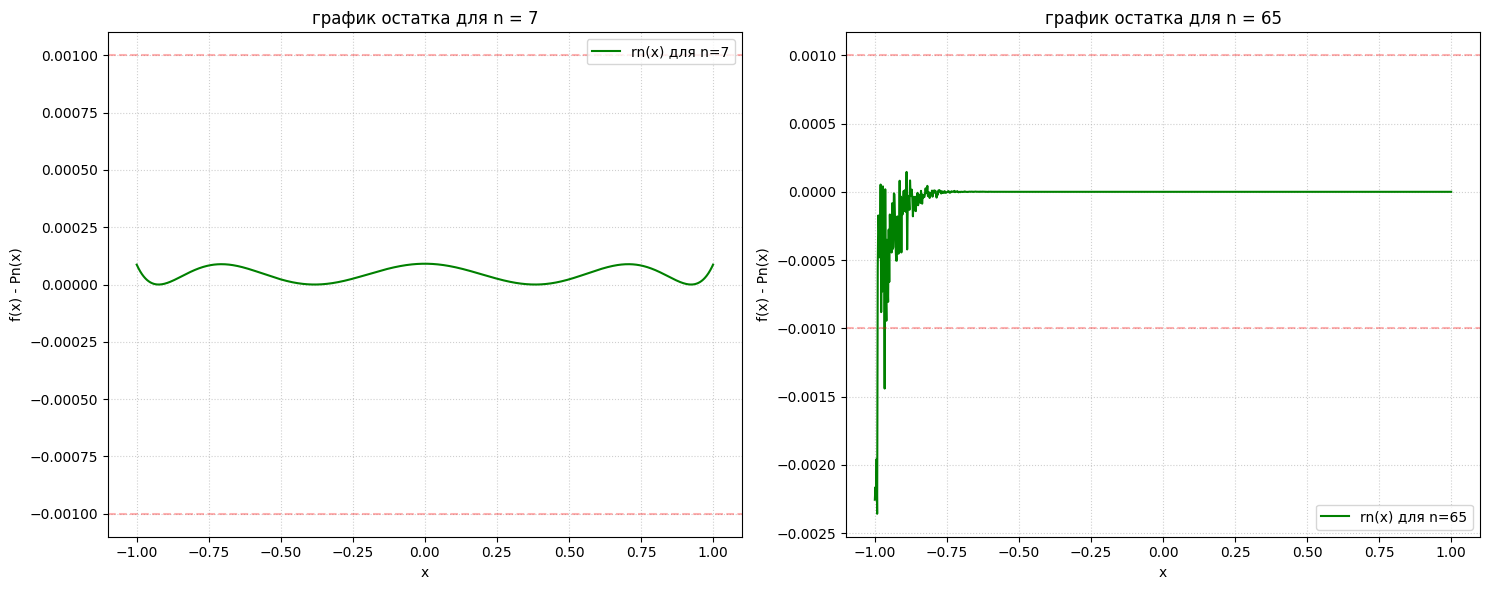

In [10]:
# степени
degrees_to_plot = [7, 65]

plt.figure(figsize=(15, 6))

for i, n_val in enumerate(degrees_to_plot):
    # многочлен
    n_nodes = (n_val + 1) // 2
    nodes = get_chebyshev_nodes(n_nodes - 1, a, b)
    xi_exp, alphas = build_hermite_table(nodes)
    
    # считаем значения
    x_plot = np.linspace(a, b, 1000)
    y_true_plot = f(x_plot)
    y_poly_plot = np.array([hornering(x, xi_exp, alphas) for x in x_plot])
    
    # остаток
    residual = y_true_plot - y_poly_plot
    
    # рисуем
    plt.subplot(1, 2, i + 1)
    plt.plot(x_plot, residual, 'g-', label=f'rn(x) для n={n_val}')
    
    plt.axhline(y=1e-3, color='r', linestyle='--', alpha=0.3)
    plt.axhline(y=-1e-3, color='r', linestyle='--', alpha=0.3)
    
    plt.title(f'график остатка для n = {n_val}')
    plt.xlabel('x')
    plt.ylabel('f(x) - Pn(x)')
    plt.grid(True, ls=':', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

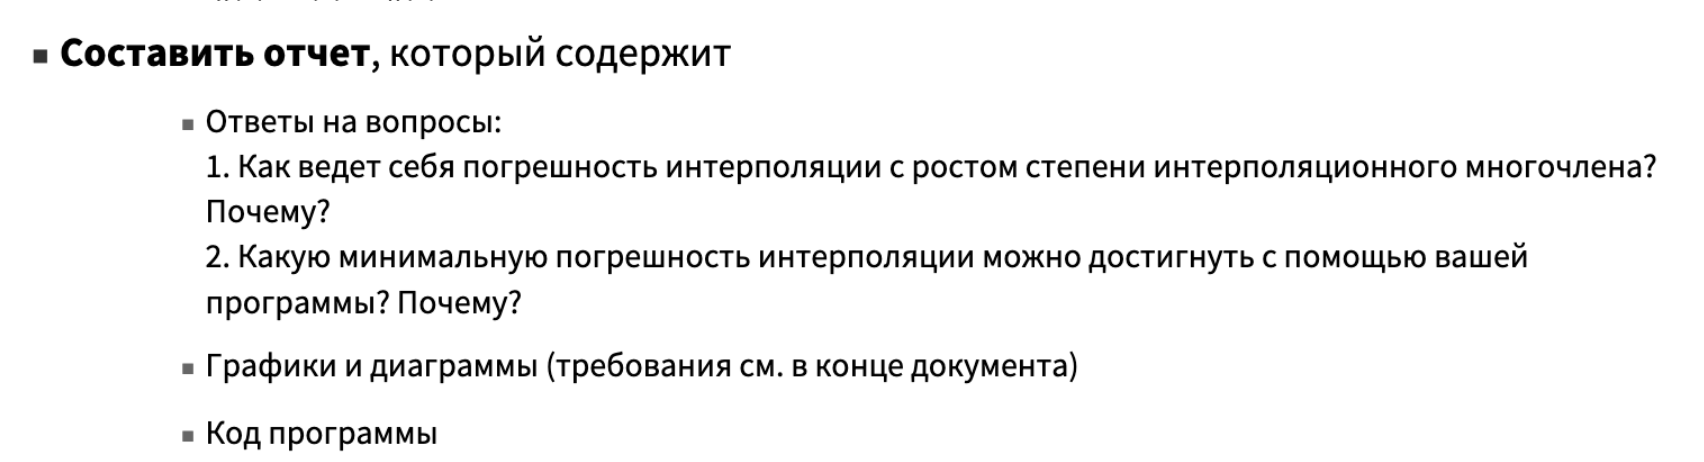

In [ ]:
import sys
print(sys.float_info.epsilon)
print(sys.float_info.min)

2.220446049250313e-16
2.2250738585072014e-308


# Как ведет себя погрешность интерполяции с ростом степени интерполяционного многочлена?

еще раз посмотрим на график

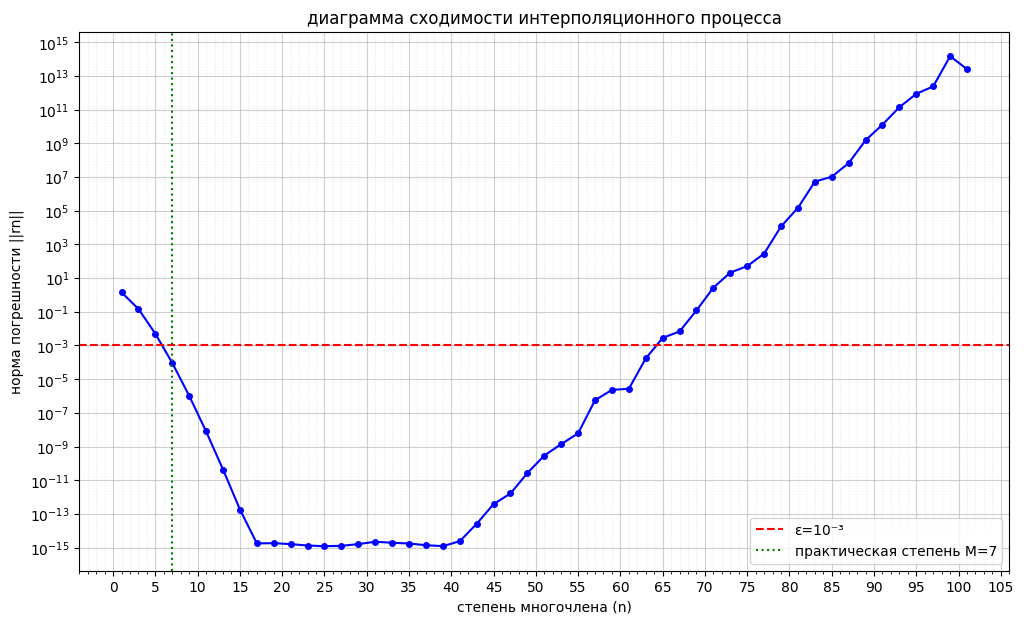

как мы видим, сначала погрешность стремительно падает, 
затем достигает "низа" (так как мы используем float64, то там $\varepsilon \approx 2.22 \cdot 10^{-16}$ (фрагмент кода выше)),
а далее, с некоторой степени, снова поднимается вверх

# Почему?

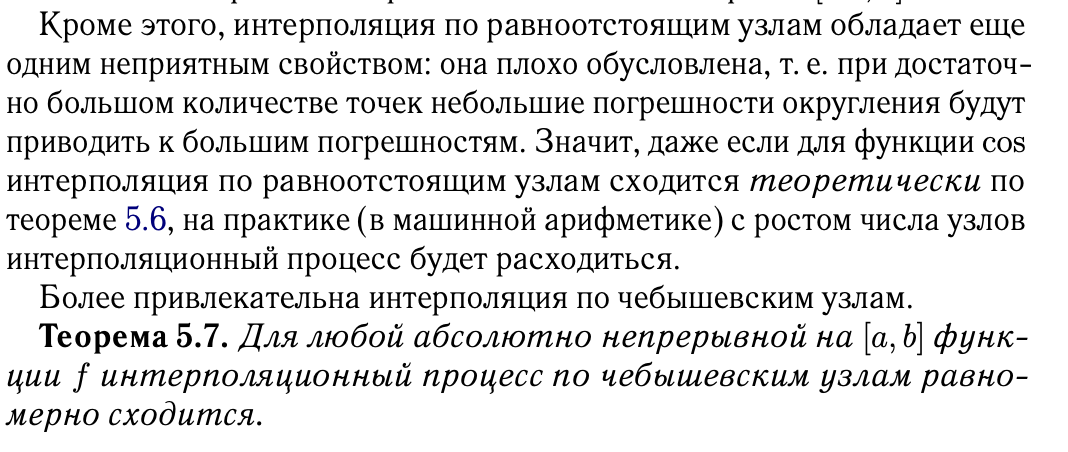

процесс интерполяции при большом числе узлов становится плохо обусловленным. то есть, это значит, что малые погрешности (в моем случае с float64) приводят к больишм ошибкам в результате. 

в форме Ньютона это проявляется при вычислении разделенных разностей (из-за деления на малые разности близких узлов, погрешности округления накапливаются и вызывают расходимость на практике, несмотря на сходимость метода)


# Какую минимальную погрешность интерполяции можно достигнуть с помощью вашей программы?

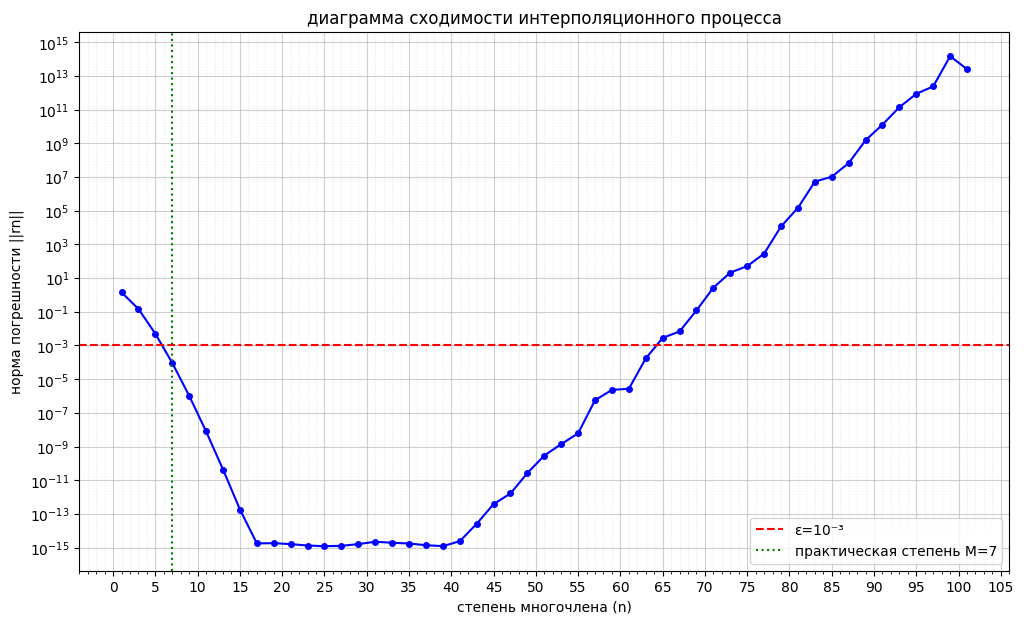

из диограммы сходимости, минимальная норма погрешности составила $10^{-15}$, что достигается в диапазоне от $n \approx 17$ до $n \approx 40$.

# Почему?

связано с тем, что -- программа написана на Python с использованием NumPy, где типом данных для дробных чисел является `float64`. точность для которого составляет $\varepsilon_{mach} \approx 2.22 \cdot 10^{-16}$.

в теории можно получить еще более точный результат (воспользоваться `mpmath`, например)
